# Notebook 04: Centralized Machine Learning Baseline (Ideal Benchmark)

## Objective
This notebook evaluates a **Centralized Baseline Model** trained by pooling all hospital datasets together.
This represents the **Theoretical Upper Bound (Ideal Performance)** achievable if data privacy was ignored and raw data was centrally aggregated.



In [1]:
import os
import sys
# Ensure project root is in sys.path for backend and scripts imports
root_path = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.path.abspath('.')
if root_path not in sys.path:
    sys.path.insert(0, root_path)
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from backend.ml.model import DiabetesRiskModel

# Load all hospital data
ha = pd.read_csv(os.path.join(root_path, "data", "hospitals", "hospital_A.csv"))
hb = pd.read_csv(os.path.join(root_path, "data", "hospitals", "hospital_B.csv"))
hc = pd.read_csv(os.path.join(root_path, "data", "hospitals", "hospital_C.csv"))

df_centralized = pd.concat([ha, hb, hc], ignore_index=True)
print(f"Total Centralized Pooled Records: {len(df_centralized)}")


Total Centralized Pooled Records: 1500


## 1. Feature Preprocessing & Split


In [2]:
feature_cols = ['age', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'bmi', 'glucose', 'hba1c', 'cholesterol', 'creatinine']
target_col = 'diabetes'

X = df_centralized[feature_cols].values
y = df_centralized[target_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train Shape: {X_train_scaled.shape}, Test Shape: {X_test_scaled.shape}")


Train Shape: (1200, 9), Test Shape: (300, 9)


## 2. Train Traditional ML Models (Logistic Regression & Random Forest)


In [3]:
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Classical ML Baseline Results:")
print(f"Logistic Regression - Acc: {accuracy_score(y_test, lr_preds):.4f}, F1: {f1_score(y_test, lr_preds):.4f}, AUC: {roc_auc_score(y_test, lr_probs):.4f}")
print(f"Random Forest       - Acc: {accuracy_score(y_test, rf_preds):.4f}, F1: {f1_score(y_test, rf_preds):.4f}, AUC: {roc_auc_score(y_test, rf_probs):.4f}")


Classical ML Baseline Results:
Logistic Regression - Acc: 0.9533, F1: 0.9613, AUC: 0.9648
Random Forest       - Acc: 0.9633, F1: 0.9692, AUC: 0.9665


## 3. Train PyTorch Deep Learning Model (`DiabetesRiskModel`)


In [4]:
train_ds = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

model = DiabetesRiskModel(input_dim=len(feature_cols))
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 25
losses = []

model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for bx, by in train_loader:
        optimizer.zero_grad()
        out = model(bx).squeeze()
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(bx)
    epoch_loss /= len(X_train_scaled)
    losses.append(epoch_loss)

print("PyTorch Model Training Complete.")


PyTorch Model Training Complete.


## 4. Evaluate Centralized PyTorch Model


In [5]:
model.eval()
all_preds = []
all_probs = []

with torch.no_grad():
    for bx, by in test_loader:
        out = model(bx).squeeze()
        probs = torch.sigmoid(out)
        preds = (probs >= 0.5).float()
        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())

nn_acc = accuracy_score(y_test, all_preds)
nn_f1 = f1_score(y_test, all_preds)
nn_prec = precision_score(y_test, all_preds)
nn_rec = recall_score(y_test, all_preds)
nn_auc = roc_auc_score(y_test, all_probs)

print(f"Centralized PyTorch Baseline:")
print(f"Accuracy:  {nn_acc:.4f}")
print(f"Precision: {nn_prec:.4f}")
print(f"Recall:    {nn_rec:.4f}")
print(f"F1 Score:  {nn_f1:.4f}")
print(f"ROC-AUC:   {nn_auc:.4f}")


Centralized PyTorch Baseline:
Accuracy:  0.9467
Precision: 0.9355
Recall:    0.9775
F1 Score:  0.9560
ROC-AUC:   0.9660


## 5. ROC Curve & Loss Curve Plot


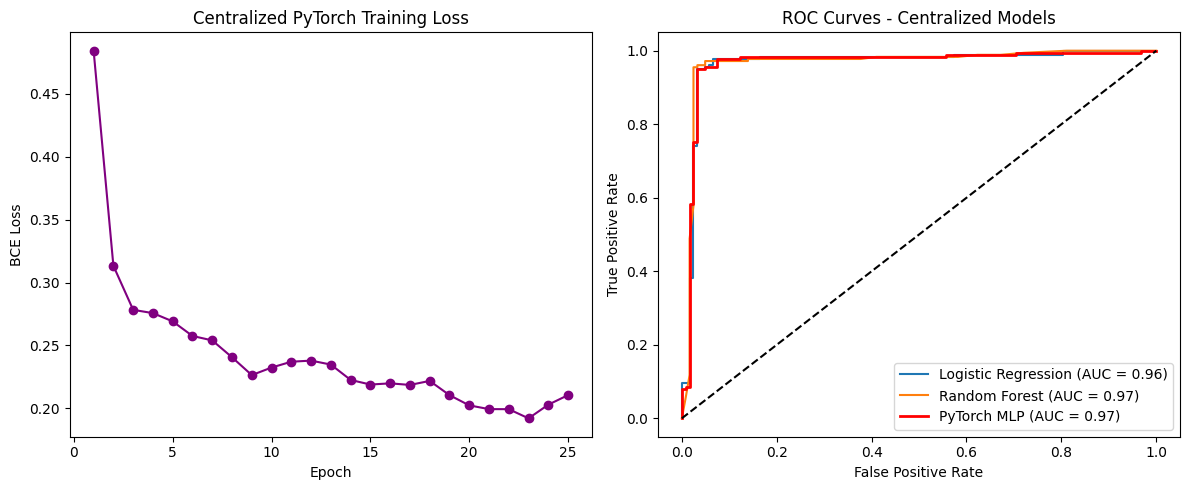

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss curve
ax1.plot(range(1, epochs+1), losses, marker='o', color='purple')
ax1.set_title("Centralized PyTorch Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_nn, tpr_nn, _ = roc_curve(y_test, all_probs)

ax2.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.2f})')
ax2.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.2f})')
ax2.plot(fpr_nn, tpr_nn, label=f'PyTorch MLP (AUC = {nn_auc:.2f})', linewidth=2, color='red')
ax2.plot([0, 1], [0, 1], 'k--')
ax2.set_title("ROC Curves - Centralized Models")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend()

plt.tight_layout()
plt.show()
